## Analisis Korelasi dan Prediksi Harga Bitcoin Berdasarkan Harga Emas dan Minyak Menggunakan XGBoost

## Problem

Bitcoin merupakan aset digital yang memiliki pergerakan harga yang relatif dinamis. 
Perubahan harga Bitcoin dapat dipengaruhi oleh berbagai kondisi pasar dan faktor ekonomi.

Emas merupakan salah satu aset yang sering digunakan sebagai instrumen penyimpan nilai,
sedangkan minyak merupakan salah satu komoditas penting yang mencerminkan kondisi ekonomi
dan aktivitas pasar global.

Penelitian ini menggunakan data historis Bitcoin, emas, dan minyak selama kurang lebih
6 tahun untuk mengetahui pola pergerakan harga, hubungan antar aset, serta menguji apakah
informasi historis Bitcoin, emas, dan minyak dapat digunakan untuk memprediksi harga Bitcoin.

Data diperoleh melalui proses ETL menggunakan Apache Airflow dan disimpan dalam database MySQL.

* Nama: Rahmi
* NIM: E1E14048

## Pertanyaan Bisnis

* Bagaimana tren perubahan harga Bitcoin, emas, dan minyak selama periode 2020–2026?
* Seberapa kuat hubungan antara harga Bitcoin dan harga emas selama periode 2020–2026?
* Seberapa kuat hubungan antara harga Bitcoin dan harga minyak selama periode 2020–2026?
* Bagaimana pola perubahan harga emas dan minyak ketika harga Bitcoin mengalami kenaikan atau penurunan selama periode 2020–2026?

## Import Packages/Library 

In [1]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ============================================================
# IMPORT PACKAGE
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import mysql.connector
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

from IPython.display import display

print("Semua package berhasil di-import.")

Semua package berhasil di-import.


In [4]:
# ============================================================
# MYSQL CONNECTION
# ============================================================

conn = mysql.connector.connect(
    host="localhost",
    port=3306,
    user="root",
    password="root",
    database="market_db"
)

print("Koneksi MySQL berhasil.")

Koneksi MySQL berhasil.


## Data Wrangling

# Gathering Data

In [5]:
# memuat data
bitcoin = pd.read_sql(
    """
    SELECT *
    FROM bitcoin_prices
    ORDER BY recorded_date
    """,
    conn
)

display(bitcoin.head())

,id,recorded_date,btc_price,created_at
0,1,2020-10-04,10671.11,2026-10-04 13:44:39
1,2,2020-10-05,10795.00,2026-10-04 13:44:39
2,3,2020-10-06,10602.66,2026-10-04 13:44:39
3,4,2020-10-07,10670.47,2026-10-04 13:44:39
4,5,2020-10-08,10933.09,2026-10-04 13:44:39


In [6]:
# memuat data
gold = pd.read_sql(
    """
    SELECT *
    FROM gold_prices
    ORDER BY recorded_date
    """,
    conn
)

display(gold.head())

,id,recorded_date,gold_price,created_at
0,1,2020-10-04,1903.927803,2026-10-04 13:53:04
1,2,2020-10-05,1912.451750,2026-10-04 13:53:04
2,3,2020-10-06,1878.993770,2026-10-04 13:53:04
3,4,2020-10-07,1887.030989,2026-10-04 13:53:04
4,5,2020-10-08,1894.110839,2026-10-04 13:53:04


In [7]:
# memuat data
oil = pd.read_sql(
    """
    SELECT *
    FROM oil_prices
    ORDER BY recorded_date
    """,
    conn
)

display(oil.head())

,id,recorded_date,oil_price,created_at
0,1,2020-10-05,39.12,2026-10-04 13:44:40
1,2,2020-10-06,40.52,2026-10-04 13:44:40
2,3,2020-10-07,39.82,2026-10-04 13:44:40
3,4,2020-10-08,41.04,2026-10-04 13:44:40
4,5,2020-10-09,40.44,2026-10-04 13:44:40


In [8]:
print("Jumlah data:")
print(f"Bitcoin : {len(bitcoin)}")
print(f"Gold    : {len(gold)}")
print(f"Oil     : {len(oil)}")

Jumlah data:
Bitcoin : 2194
Gold    : 2193
Oil     : 1495


**Insight:**
* Bitcoin mengalami penurunan pada 6 Oktober lalu kembali naik hingga 8 Oktober. Emas juga mengalami pola yang mirip, sedangkan minyak cenderung lebih berfluktuasi.
* Pergerakan BTC dan emas terlihat cukup searah pada beberapa hari. Ini bisa menjadi indikasi awal adanya hubungan, tetapi belum cukup untuk menyimpulkan korelasi.
* Pergerakan BTC dan minyak tidak selalu searah. Pada 5–6 Oktober, BTC turun sementara minyak naik. Ini menunjukkan kemungkinan hubungan yang lebih lemah dibandingkan BTC–emas.
* Bitcoin mengalami perubahan harga yang relatif lebih besar dibandingkan emas. Artinya, BTC cenderung lebih volatil dalam periode tersebut.
* Emas terlihat lebih stabil, minyak mengalami fluktuasi, sedangkan Bitcoin memiliki perubahan harga yang lebih tajam.

# Assessing Data

In [9]:
bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2194 entries, 0 to 2193
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             2194 non-null   int64         
 1   recorded_date  2194 non-null   object        
 2   btc_price      2194 non-null   float64       
 3   created_at     2194 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 68.7+ KB


In [10]:
display(bitcoin.describe())

,id,btc_price,created_at
count,2194.000000,2194.000000,2194
mean,1107.491796,55313.975410,2026-10-04 13:47:15.033728768
min,1.000000,10602.660000,2026-10-04 13:44:39
25%,549.250000,29418.727500,2026-10-04 13:44:39
50%,1097.500000,50914.995000,2026-10-04 13:44:39
75%,1645.750000,73810.027500,2026-10-04 13:44:39
max,13155.000000,124720.090000,2026-10-06 13:17:28
std,729.863894,28904.735516,NaN


In [11]:
print("Missing Value Bitcoin:")
print(bitcoin.isnull().sum())

Missing Value Bitcoin:
id               0
recorded_date    0
btc_price        0
created_at       0
dtype: int64


In [12]:
print("Jumlah data duplikat Bitcoin:")
print(bitcoin.duplicated().sum())

Jumlah data duplikat Bitcoin:
0


In [13]:
print("Shape Bitcoin:", bitcoin.shape)

Shape Bitcoin: (2194, 4)


In [14]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             2193 non-null   int64         
 1   recorded_date  2193 non-null   object        
 2   gold_price     2193 non-null   float64       
 3   created_at     2193 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 68.7+ KB


In [15]:
display(gold.describe())

,id,gold_price,created_at
count,2193.000000,2193.000000,2193
mean,1097.000000,2546.000199,2026-10-04 13:55:39.644322816
min,1.000000,1626.069934,2026-10-04 13:53:04
25%,549.000000,1833.349956,2026-10-04 13:53:04
50%,1097.000000,1988.194894,2026-10-04 13:53:04
75%,1645.000000,3085.334173,2026-10-04 13:53:04
max,2193.000000,5477.789208,2026-10-06 13:17:28
std,633.208891,984.883617,NaN


In [16]:
print("\nMISSING VALUE:")
print(gold.isnull().sum())


MISSING VALUE:
id               0
recorded_date    0
gold_price       0
created_at       0
dtype: int64


In [17]:
print("\nDUPLIKAT:")
print(gold.duplicated().sum())


DUPLIKAT:
0


In [18]:
print("\nSHAPE:")
print(gold.shape)


SHAPE:
(2193, 4)


In [19]:
oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             1495 non-null   int64         
 1   recorded_date  1495 non-null   object        
 2   oil_price      1495 non-null   float64       
 3   created_at     1495 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 46.8+ KB


In [20]:
display(oil.describe())

,id,oil_price,created_at
count,1495.00000,1495.000000,1495
mean,748.00000,76.244000,2026-10-04 13:44:40.000000512
min,1.00000,35.640000,2026-10-04 13:44:40
25%,374.50000,66.845000,2026-10-04 13:44:40
50%,748.00000,74.680000,2026-10-04 13:44:40
75%,1121.50000,84.045000,2026-10-04 13:44:40
max,1495.00000,123.640000,2026-10-04 13:44:40
std,431.71364,15.112866,NaN


In [21]:
print("\nMISSING VALUE:")
print(oil.isnull().sum())


MISSING VALUE:
id               0
recorded_date    0
oil_price        0
created_at       0
dtype: int64


In [22]:
print("\nDUPLIKAT:")
print(oil.duplicated().sum())


DUPLIKAT:
0


In [23]:
print("\nSHAPE:")
print(oil.shape)


SHAPE:
(1495, 4)


**Insight:**
* Ketiga dataset tidak memiliki missing value maupun data duplikat, sehingga dapat digunakan untuk analisis selanjutnya.

* Harga Bitcoin berada pada rentang sekitar $10.602–$124.720, menunjukkan perubahan harga yang sangat besar selama periode penelitian.

* Meskipun harga emas meningkat cukup tinggi pada periode tertentu, pergerakannya relatif lebih stabil dibandingkan Bitcoin.

* Harga minyak berada pada kisaran $35,64–$123,64, dengan jumlah data yang lebih sedikit karena terdapat tanggal perdagangan yang tidak sama dengan Bitcoin dan emas. Hal ini karena API https://fred.stlouisfed.org/docs/api/fred/ hanya menyediakan hari bursa, bukan setiap hari kalender.

# Cleaning Data

In [24]:
bitcoin["recorded_date"] = pd.to_datetime(bitcoin["recorded_date"])
gold["recorded_date"] = pd.to_datetime(gold["recorded_date"])
oil["recorded_date"] = pd.to_datetime(oil["recorded_date"])

In [25]:
# ==============================
# KONVERSI TIPE DATA NUMERIK
# ==============================

# Bitcoin
bitcoin["btc_price"] = pd.to_numeric(
    bitcoin["btc_price"],
    errors="coerce"
)

# Gold
gold["gold_price"] = pd.to_numeric(
    gold["gold_price"],
    errors="coerce"
)

# Oil
oil["oil_price"] = pd.to_numeric(
    oil["oil_price"],
    errors="coerce"
)

# Konversi tanggal
bitcoin["recorded_date"] = pd.to_datetime(
    bitcoin["recorded_date"],
    errors="coerce"
)

gold["recorded_date"] = pd.to_datetime(
    gold["recorded_date"],
    errors="coerce"
)

oil["recorded_date"] = pd.to_datetime(
    oil["recorded_date"],
    errors="coerce"
)

In [26]:
print("Missing setelah konversi tipe:")

print("\nBitcoin")
print(bitcoin.isnull().sum())

print("\nGold")
print(gold.isnull().sum())

print("\nOil")
print(oil.isnull().sum())

Missing setelah konversi tipe:

Bitcoin
id               0
recorded_date    0
btc_price        0
created_at       0
dtype: int64

Gold
id               0
recorded_date    0
gold_price       0
created_at       0
dtype: int64

Oil
id               0
recorded_date    0
oil_price        0
created_at       0
dtype: int64


In [27]:
bitcoin = bitcoin.drop_duplicates(
    subset="recorded_date"
)

gold = gold.drop_duplicates(
    subset="recorded_date"
)

oil = oil.drop_duplicates(
    subset="recorded_date"
)

# Assessing Data Setelah Cleaning

In [28]:
print("===== BITCOIN SETELAH CLEANING =====")
print("Shape:", bitcoin.shape)

print("\nMissing:")
print(bitcoin.isnull().sum())

print("\nDuplikat:")
print(bitcoin.duplicated().sum())

print("\nInfo:")
bitcoin.info()

display(bitcoin.describe())

===== BITCOIN SETELAH CLEANING =====
Shape: (2194, 4)

Missing:
id               0
recorded_date    0
btc_price        0
created_at       0
dtype: int64

Duplikat:
0

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2194 entries, 0 to 2193
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             2194 non-null   int64         
 1   recorded_date  2194 non-null   datetime64[ns]
 2   btc_price      2194 non-null   float64       
 3   created_at     2194 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1)
memory usage: 68.7 KB


,id,recorded_date,btc_price,created_at
count,2194.000000,2194,2194.000000,2194
mean,1107.491796,2023-10-05 12:00:00,55313.975410,2026-10-04 13:47:15.033728768
min,1.000000,2020-10-04 00:00:00,10602.660000,2026-10-04 13:44:39
25%,549.250000,2022-04-05 06:00:00,29418.727500,2026-10-04 13:44:39
50%,1097.500000,2023-10-05 12:00:00,50914.995000,2026-10-04 13:44:39
75%,1645.750000,2025-04-05 18:00:00,73810.027500,2026-10-04 13:44:39
max,13155.000000,2026-10-06 00:00:00,124720.090000,2026-10-06 13:17:28
std,729.863894,NaN,28904.735516,NaN


In [29]:
print("===== GOLD SETELAH CLEANING =====")

print("Shape:", gold.shape)

print("\nMissing:")
print(gold.isnull().sum())

print("\nDuplikat:")
print(gold.duplicated().sum())

gold.info()

display(gold.describe())

===== GOLD SETELAH CLEANING =====
Shape: (2193, 4)

Missing:
id               0
recorded_date    0
gold_price       0
created_at       0
dtype: int64

Duplikat:
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             2193 non-null   int64         
 1   recorded_date  2193 non-null   datetime64[ns]
 2   gold_price     2193 non-null   float64       
 3   created_at     2193 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1)
memory usage: 68.7 KB


,id,recorded_date,gold_price,created_at
count,2193.000000,2193,2193.000000,2193
mean,1097.000000,2023-10-05 00:00:00,2546.000199,2026-10-04 13:55:39.644322816
min,1.000000,2020-10-04 00:00:00,1626.069934,2026-10-04 13:53:04
25%,549.000000,2022-04-05 00:00:00,1833.349956,2026-10-04 13:53:04
50%,1097.000000,2023-10-05 00:00:00,1988.194894,2026-10-04 13:53:04
75%,1645.000000,2025-04-05 00:00:00,3085.334173,2026-10-04 13:53:04
max,2193.000000,2026-10-05 00:00:00,5477.789208,2026-10-06 13:17:28
std,633.208891,NaN,984.883617,NaN


In [30]:
print("===== OIL SETELAH CLEANING =====")

print("Shape:", oil.shape)

print("\nMissing:")
print(oil.isnull().sum())

print("\nDuplikat:")
print(oil.duplicated().sum())

oil.info()

display(oil.describe())

===== OIL SETELAH CLEANING =====
Shape: (1495, 4)

Missing:
id               0
recorded_date    0
oil_price        0
created_at       0
dtype: int64

Duplikat:
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             1495 non-null   int64         
 1   recorded_date  1495 non-null   datetime64[ns]
 2   oil_price      1495 non-null   float64       
 3   created_at     1495 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1)
memory usage: 46.8 KB


,id,recorded_date,oil_price,created_at
count,1495.00000,1495,1495.000000,1495
mean,748.00000,2023-09-30 08:49:45.953177344,76.244000,2026-10-04 13:44:40.000000512
min,1.00000,2020-10-05 00:00:00,35.640000,2026-10-04 13:44:40
25%,374.50000,2022-03-31 12:00:00,66.845000,2026-10-04 13:44:40
50%,748.00000,2023-09-27 00:00:00,74.680000,2026-10-04 13:44:40
75%,1121.50000,2025-03-31 12:00:00,84.045000,2026-10-04 13:44:40
max,1495.00000,2026-09-29 00:00:00,123.640000,2026-10-04 13:44:40
std,431.71364,NaN,15.112866,NaN


# Menggabungkan Data

In [31]:
# ==========================================
# MEMILIH KOLOM YANG DIBUTUHKAN
# ==========================================

bitcoin_selected = bitcoin[
    ["recorded_date", "btc_price"]
].copy()

gold_selected = gold[
    ["recorded_date", "gold_price"]
].copy()

oil_selected = oil[
    ["recorded_date", "oil_price"]
].copy()


# ==========================================
# PASTIKAN TIPE DATA TANGGAL
# ==========================================

bitcoin_selected["recorded_date"] = pd.to_datetime(
    bitcoin_selected["recorded_date"],
    errors="coerce"
)

gold_selected["recorded_date"] = pd.to_datetime(
    gold_selected["recorded_date"],
    errors="coerce"
)

oil_selected["recorded_date"] = pd.to_datetime(
    oil_selected["recorded_date"],
    errors="coerce"
)


# ==========================================
# HAPUS TANGGAL YANG TIDAK VALID
# ==========================================

bitcoin_selected = bitcoin_selected.dropna(subset=["recorded_date"])
gold_selected = gold_selected.dropna(subset=["recorded_date"])
oil_selected = oil_selected.dropna(subset=["recorded_date"])


# ==========================================
# URUTKAN BERDASARKAN TANGGAL
# ==========================================

bitcoin_selected = bitcoin_selected.sort_values("recorded_date")
gold_selected = gold_selected.sort_values("recorded_date")
oil_selected = oil_selected.sort_values("recorded_date")


# ==========================================
# MERGE BITCOIN DENGAN GOLD
# ==========================================

merged_data = bitcoin_selected.merge(
    gold_selected,
    on="recorded_date",
    how="left"
)


# ==========================================
# MERGE DENGAN OIL
# ==========================================

merged_data = merged_data.merge(
    oil_selected,
    on="recorded_date",
    how="left"
)


# ==========================================
# URUTKAN BERDASARKAN TANGGAL
# ==========================================

merged_data = merged_data.sort_values(
    "recorded_date"
).reset_index(drop=True)


# ==========================================
# ISI MISSING VALUE DENGAN NILAI TERAKHIR
# ==========================================

merged_data["gold_price"] = merged_data["gold_price"].ffill()

merged_data["oil_price"] = merged_data["oil_price"].ffill()

# Hapus baris yang masih memiliki missing value
merged_data = merged_data.dropna()


# ==========================================
# TAMPILKAN HASIL
# ==========================================

display(merged_data.head(10))

,recorded_date,btc_price,gold_price,oil_price
1,2020-10-05,10795.00,1912.451750,39.12
2,2020-10-06,10602.66,1878.993770,40.52
3,2020-10-07,10670.47,1887.030989,39.82
4,2020-10-08,10933.09,1894.110839,41.04
5,2020-10-09,11057.07,1930.082399,40.44
6,2020-10-10,11299.50,1930.408764,40.44
7,2020-10-11,11374.01,1929.868576,40.44
8,2020-10-12,11535.46,1924.538817,39.22
9,2020-10-13,11428.22,1892.682826,40.03
10,2020-10-14,11427.70,1898.926236,40.86


In [32]:
print("Shape data gabungan:", merged_data.shape)

print("\nMissing Value:")
print(merged_data.isnull().sum())

print("\nDuplikat:")
print(merged_data.duplicated().sum())

Shape data gabungan: (2193, 4)

Missing Value:
recorded_date    0
btc_price        0
gold_price       0
oil_price        0
dtype: int64

Duplikat:
0


# Explanatory Data Analysis (EDA)

**Explore...**

**1. Bagaimana tren perubahan harga Bitcoin, emas, dan minyak selama periode 2020–2026?**

In [33]:
merged_data_index = merged_data.copy()

merged_data_index["Bitcoin"] = (
    merged_data_index["btc_price"] / merged_data_index["btc_price"].iloc[0]
) * 100

merged_data_index["Gold"] = (
    merged_data_index["gold_price"] / merged_data_index["gold_price"].iloc[0]
) * 100

merged_data_index["Oil"] = (
    merged_data_index["oil_price"] / merged_data_index["oil_price"].iloc[0]
) * 100

print(merged_data_index[
    ["recorded_date", "Bitcoin", "Gold", "Oil"]
].head(10))

   recorded_date     Bitcoin        Gold         Oil
1     2020-10-05  100.000000  100.000000  100.000000
2     2020-10-06   98.218249   98.250519  103.578732
3     2020-10-07   98.846410   98.670776  101.789366
4     2020-10-08  101.279203   99.040974  104.907975
5     2020-10-09  102.427698  100.921887  103.374233
6     2020-10-10  104.673460  100.938953  103.374233
7     2020-10-11  105.363687  100.910707  103.374233
8     2020-10-12  106.859287  100.632019  100.255624
9     2020-10-13  105.865864   98.966305  102.326176
10    2020-10-14  105.861047   99.292766  104.447853


**2. Seberapa kuat hubungan antara harga Bitcoin dan harga emas selama periode 2020–2026?**

In [34]:
r = merged_data["btc_price"].corr(merged_data["gold_price"])

if abs(r) < 0.20:
    kekuatan = "sangat lemah"
elif abs(r) < 0.40:
    kekuatan = "lemah"
elif abs(r) < 0.60:
    kekuatan = "sedang"
elif abs(r) < 0.80:
    kekuatan = "kuat"
else:
    kekuatan = "sangat kuat"

arah = "positif/searah" if r > 0 else "negatif/berlawanan"

print(f"Nilai korelasi: {r:.4f}")
print(f"Kekuatan hubungan: {kekuatan}")
print(f"Arah hubungan: {arah}")

Nilai korelasi: 0.6981
Kekuatan hubungan: kuat
Arah hubungan: positif/searah


**3. Seberapa kuat hubungan antara harga Bitcoin dan harga minyak selama periode 2020–2026?**

In [35]:
r = merged_data["btc_price"].corr(merged_data["oil_price"])

if abs(r) < 0.20:
    kekuatan = "sangat lemah"
elif abs(r) < 0.40:
    kekuatan = "lemah"
elif abs(r) < 0.60:
    kekuatan = "sedang"
elif abs(r) < 0.80:
    kekuatan = "kuat"
else:
    kekuatan = "sangat kuat"

if r > 0:
    arah = "positif (searah)"
elif r < 0:
    arah = "negatif (berlawanan)"
else:
    arah = "tidak ada hubungan"

print(f"Nilai korelasi: {r:.4f}")
print(f"Kekuatan hubungan: {kekuatan}")
print(f"Arah hubungan: {arah}")

Nilai korelasi: -0.1934
Kekuatan hubungan: sangat lemah
Arah hubungan: negatif (berlawanan)


** 4.Bagaimana pola perubahan harga emas dan minyak ketika harga Bitcoin mengalami kenaikan atau penurunan selama periode 2020–2026?**

In [36]:
# Pastikan data diurutkan berdasarkan tanggal
merged_data = merged_data.sort_values("recorded_date").reset_index(drop=True)

# Hitung perubahan harga harian (%)
merged_data["btc_change"] = merged_data["btc_price"].pct_change() * 100
merged_data["gold_change"] = merged_data["gold_price"].pct_change() * 100
merged_data["oil_change"] = merged_data["oil_price"].pct_change() * 100

# Buat kategori berdasarkan perubahan Bitcoin
merged_data["btc_condition"] = merged_data["btc_change"].apply(
    lambda x: "Naik" if x > 0 else "Turun" if x < 0 else "Tetap"
)

# Hitung rata-rata perubahan emas dan minyak
hasil_pola = merged_data.groupby("btc_condition")[
    ["btc_change", "gold_change", "oil_change"]
].mean()

print("RATA-RATA PERUBAHAN HARGA")
print(hasil_pola.round(2))

RATA-RATA PERUBAHAN HARGA
               btc_change  gold_change  oil_change
btc_condition                                     
Naik                 2.19         0.05        0.06
Tetap                 NaN          NaN         NaN
Turun               -1.94         0.03        0.07


In [37]:
# Interpretasi Pola

for kondisi in ["Naik", "Turun"]:
    btc = hasil_pola.loc[kondisi, "btc_change"]
    gold = hasil_pola.loc[kondisi, "gold_change"]
    oil = hasil_pola.loc[kondisi, "oil_change"]

    print(f"\nKetika Bitcoin {kondisi}:")
    print(f"- Bitcoin : {btc:.2f}%")
    print(f"- Emas    : {gold:.2f}%")
    print(f"- Minyak  : {oil:.2f}%")


Ketika Bitcoin Naik:
- Bitcoin : 2.19%
- Emas    : 0.05%
- Minyak  : 0.06%

Ketika Bitcoin Turun:
- Bitcoin : -1.94%
- Emas    : 0.03%
- Minyak  : 0.07%


**Insight:**
* Bitcoin dan emas memiliki hubungan positif yang kuat, dengan nilai korelasi 0,6981. Artinya, selama periode penelitian, pergerakan harga Bitcoin dan emas cenderung bergerak searah. Ketika harga emas mengalami kenaikan, harga Bitcoin juga cenderung mengalami kenaikan, dan sebaliknya.
* Bitcoin dan minyak memiliki hubungan negatif yang sangat lemah, dengan nilai korelasi -0,1934. Artinya, pergerakan harga Bitcoin dan minyak cenderung berlawanan arah, tetapi hubungannya sangat kecil sehingga perubahan harga minyak tidak menunjukkan hubungan yang kuat dengan perubahan harga Bitcoin.
* Dari kedua variabel pembanding, emas memiliki hubungan yang jauh lebih kuat dengan Bitcoin dibandingkan minyak. Hal ini terlihat dari nilai korelasi 0,6981 pada emas, sedangkan minyak hanya -0,1934.
* Ketika Bitcoin mengalami kenaikan maupun penurunan, harga emas dan minyak cenderung tetap mengalami kenaikan rata-rata. Hal ini menunjukkan bahwa pola perubahan emas dan minyak tidak selalu mengikuti arah perubahan Bitcoin.

# Visualization & Explanatory Analysis

**1. Bagaimana tren perubahan harga Bitcoin, emas, dan minyak selama periode 2020–2026?**

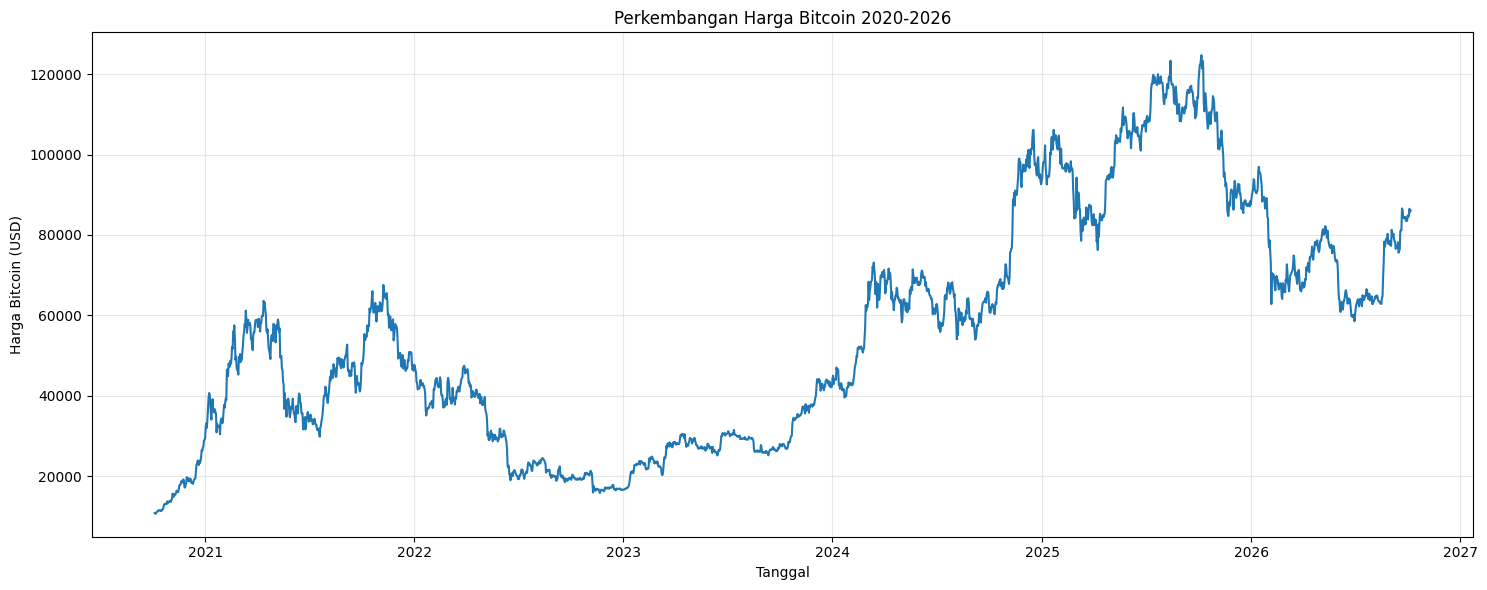

In [38]:
plt.figure(figsize=(15, 6))

plt.plot(
    merged_data["recorded_date"],
    merged_data["btc_price"]
)

plt.title("Perkembangan Harga Bitcoin 2020-2026")
plt.xlabel("Tanggal")
plt.ylabel("Harga Bitcoin (USD)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

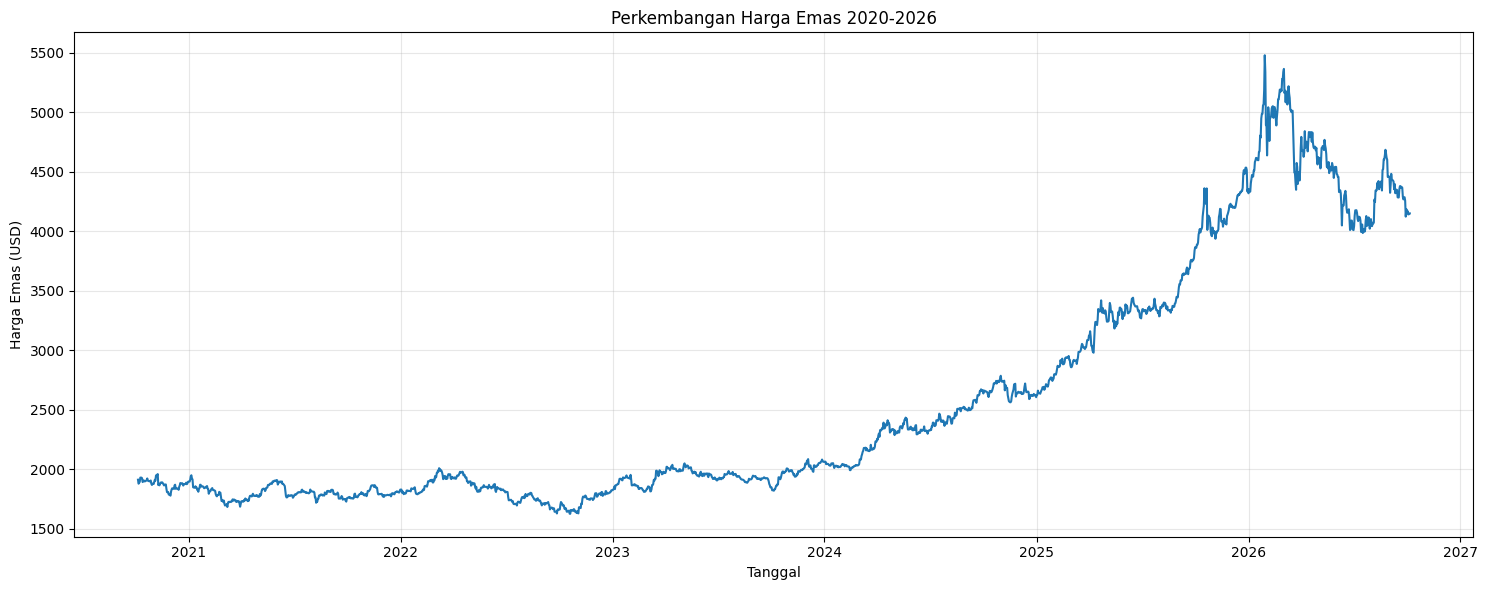

In [39]:
plt.figure(figsize=(15, 6))

plt.plot(
    merged_data["recorded_date"],
    merged_data["gold_price"]
)

plt.title("Perkembangan Harga Emas 2020-2026")
plt.xlabel("Tanggal")
plt.ylabel("Harga Emas (USD)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

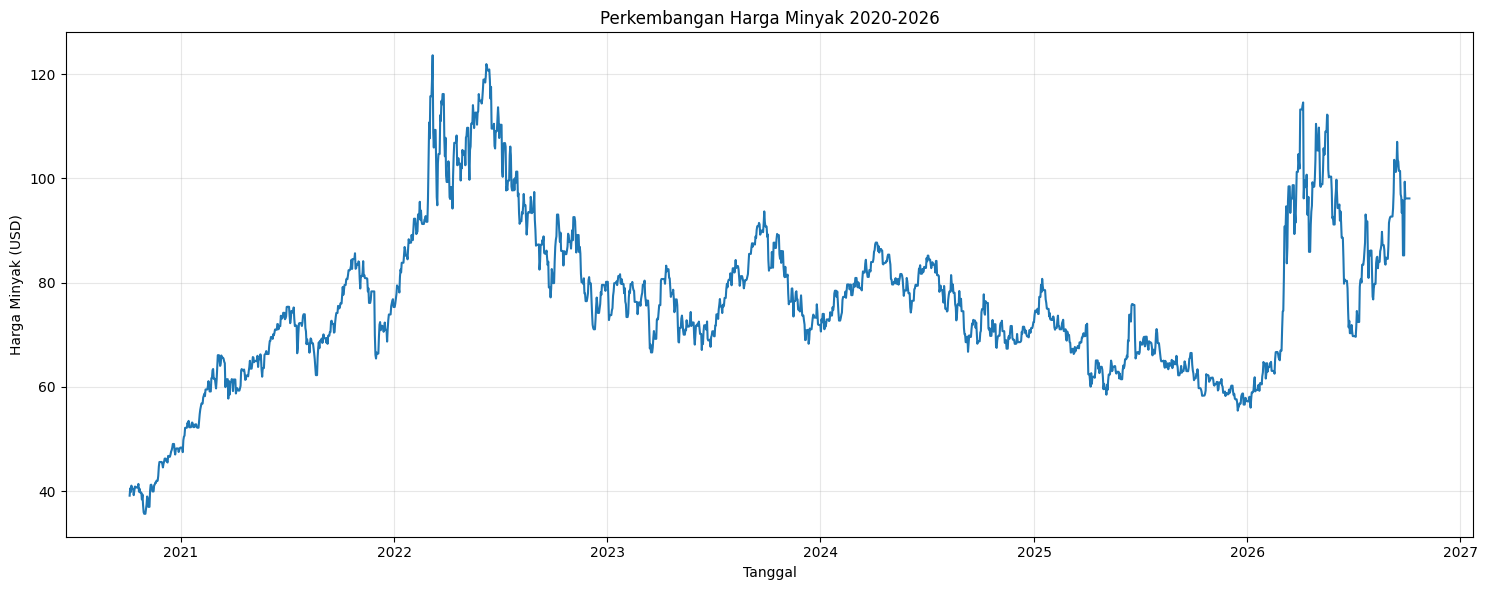

In [40]:
plt.figure(figsize=(15, 6))

plt.plot(
    merged_data["recorded_date"],
    merged_data["oil_price"]
)

plt.title("Perkembangan Harga Minyak 2020-2026")
plt.xlabel("Tanggal")
plt.ylabel("Harga Minyak (USD)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
normalized = merged_data.copy()

for col in ["btc_price", "gold_price", "oil_price"]:
    normalized[col] = (
        normalized[col] /
        normalized[col].iloc[0]
    ) * 100

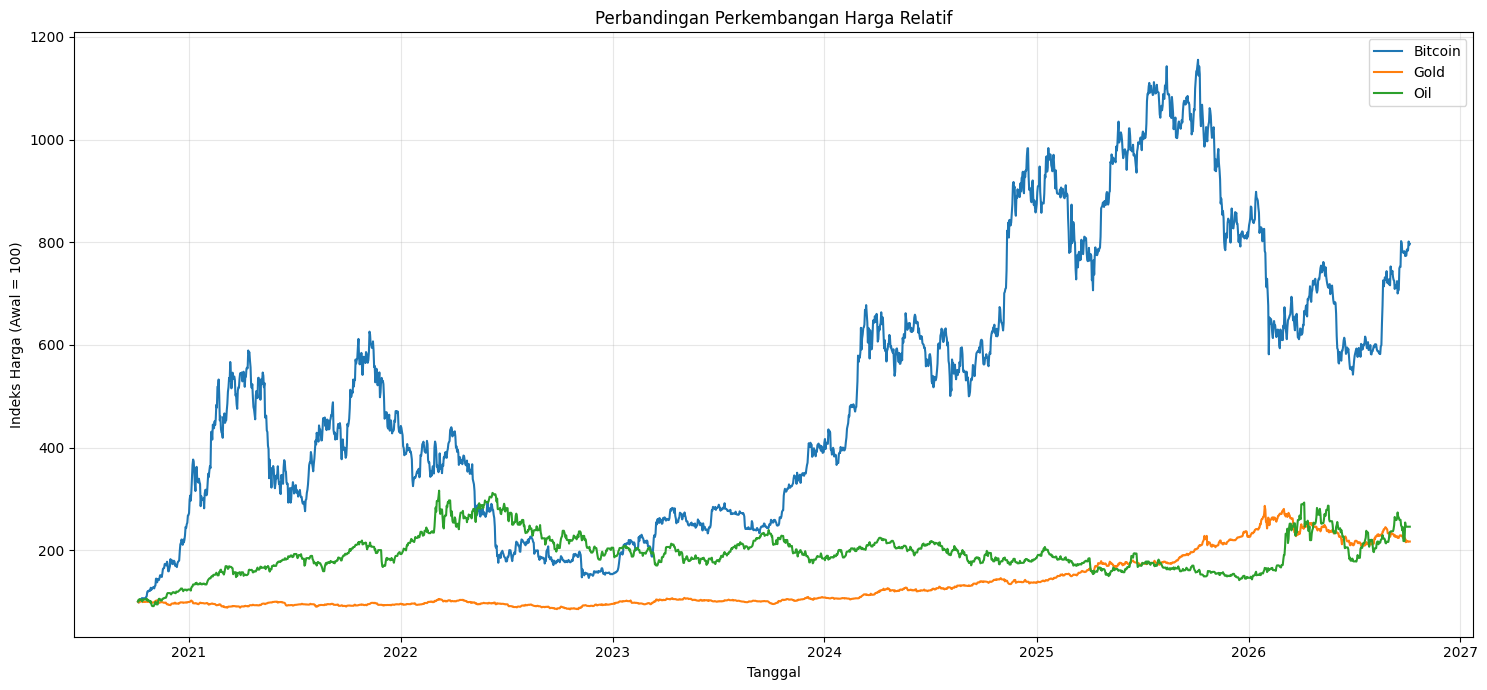

In [42]:
plt.figure(figsize=(15, 7))

plt.plot(
    normalized["recorded_date"],
    normalized["btc_price"],
    label="Bitcoin"
)

plt.plot(
    normalized["recorded_date"],
    normalized["gold_price"],
    label="Gold"
)

plt.plot(
    normalized["recorded_date"],
    normalized["oil_price"],
    label="Oil"
)

plt.title("Perbandingan Perkembangan Harga Relatif")
plt.xlabel("Tanggal")
plt.ylabel("Indeks Harga (Awal = 100)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
btc_gold_corr = merged_data[
    ["btc_price", "gold_price"]
].corr()

display(btc_gold_corr)

,btc_price,gold_price
btc_price,1.000000,0.698065
gold_price,0.698065,1.000000


**2. Seberapa kuat hubungan antara harga Bitcoin dan harga emas selama periode 2020–2026?**

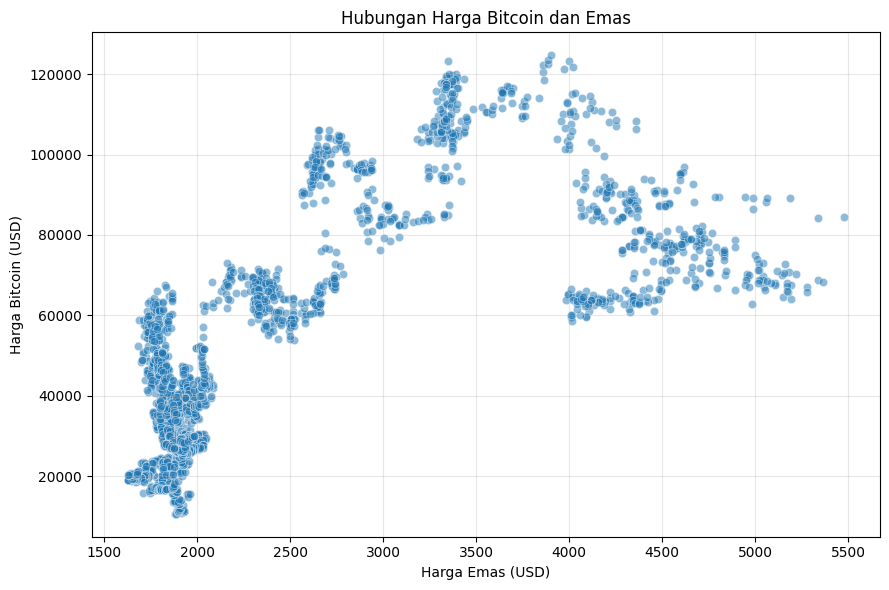

In [44]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=merged_data,
    x="gold_price",
    y="btc_price",
    alpha=0.5
)

plt.title("Hubungan Harga Bitcoin dan Emas")
plt.xlabel("Harga Emas (USD)")
plt.ylabel("Harga Bitcoin (USD)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
btc_oil_corr = merged_data[
    ["btc_price", "oil_price"]
].corr()

display(btc_oil_corr)

,btc_price,oil_price
btc_price,1.000000,-0.193388
oil_price,-0.193388,1.000000


**3. Seberapa kuat hubungan antara harga Bitcoin dan harga minyak selama periode 2020–2026?**

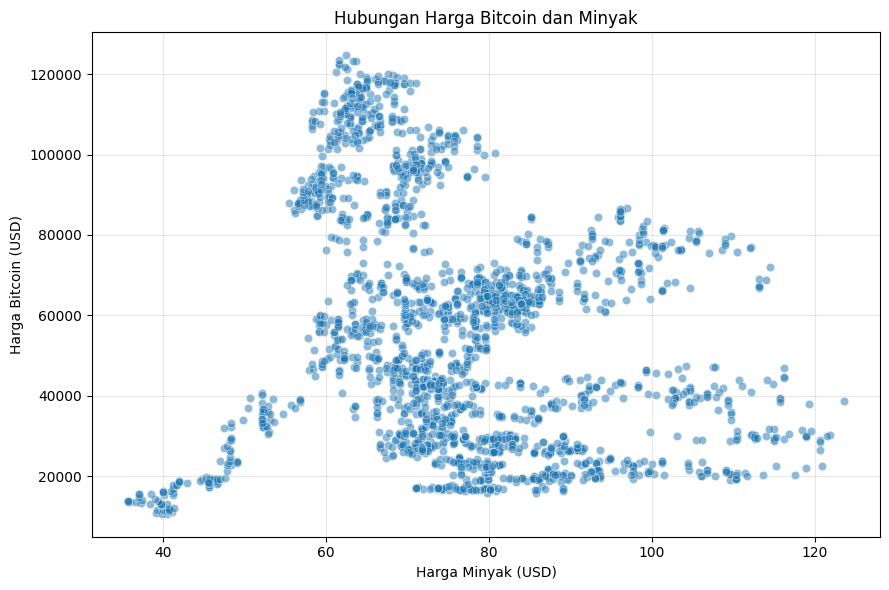

In [46]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=merged_data,
    x="oil_price",
    y="btc_price",
    alpha=0.5
)

plt.title("Hubungan Harga Bitcoin dan Minyak")
plt.xlabel("Harga Minyak (USD)")
plt.ylabel("Harga Bitcoin (USD)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

** 4.Bagaimana pola perubahan harga emas dan minyak ketika harga Bitcoin mengalami kenaikan atau penurunan selama periode 2020–2026?**

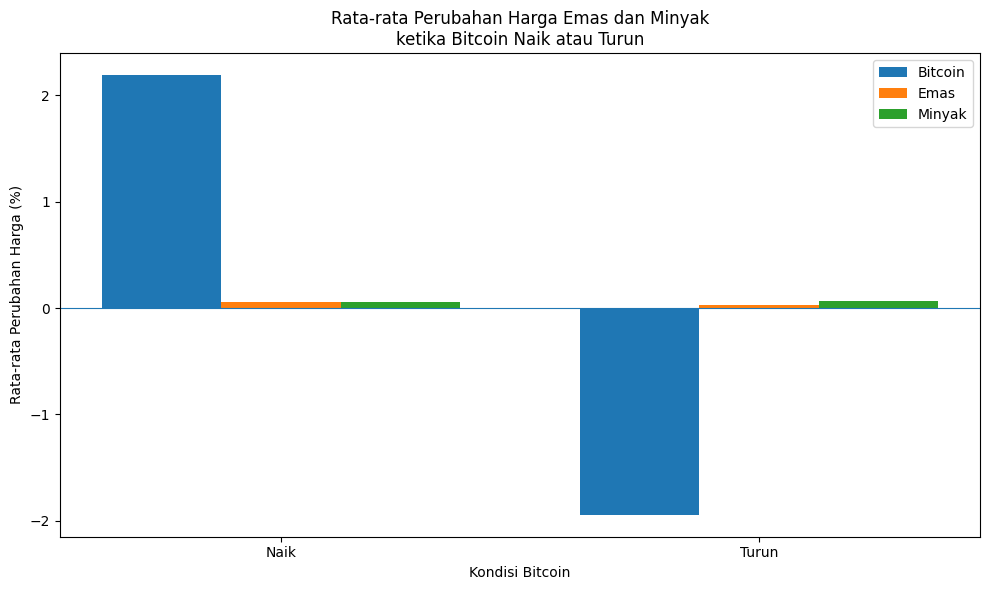

In [47]:
# Ambil data Naik dan Turun
kondisi = ["Naik", "Turun"]

btc = [
    hasil_pola.loc["Naik", "btc_change"],
    hasil_pola.loc["Turun", "btc_change"]
]

gold = [
    hasil_pola.loc["Naik", "gold_change"],
    hasil_pola.loc["Turun", "gold_change"]
]

oil = [
    hasil_pola.loc["Naik", "oil_change"],
    hasil_pola.loc["Turun", "oil_change"]
]

# Posisi batang
x = np.arange(len(kondisi))
lebar = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - lebar, btc, lebar, label="Bitcoin")
plt.bar(x, gold, lebar, label="Emas")
plt.bar(x + lebar, oil, lebar, label="Minyak")

# Garis nol
plt.axhline(0, linewidth=0.8)

plt.xticks(x, kondisi)
plt.xlabel("Kondisi Bitcoin")
plt.ylabel("Rata-rata Perubahan Harga (%)")
plt.title("Rata-rata Perubahan Harga Emas dan Minyak\nketika Bitcoin Naik atau Turun")
plt.legend()

plt.tight_layout()
plt.show()

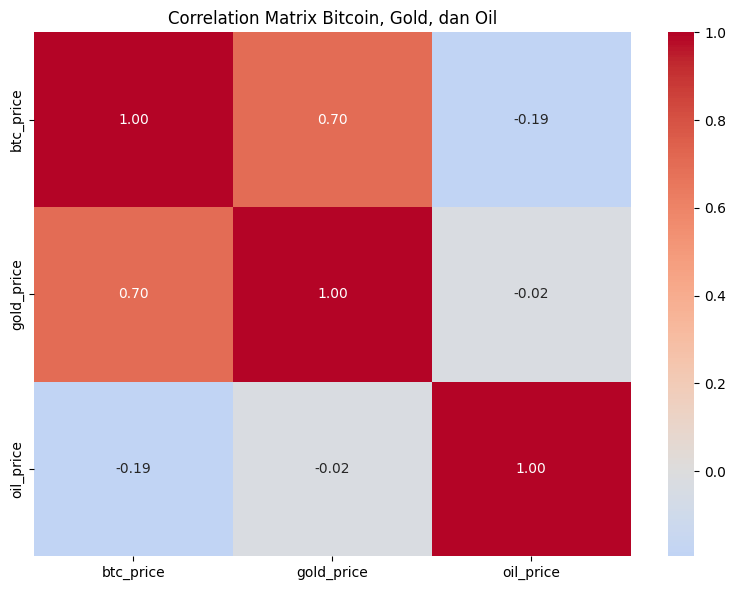

In [48]:
plt.figure(figsize=(8, 6))

correlation = merged_data[
    ["btc_price", "gold_price", "oil_price"]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix Bitcoin, Gold, dan Oil")

plt.tight_layout()
plt.show()

In [49]:
analysis_data = merged_data.copy()

analysis_data["btc_return"] = (
    analysis_data["btc_price"].pct_change()
)

analysis_data["gold_return"] = (
    analysis_data["gold_price"].pct_change()
)

analysis_data["oil_return"] = (
    analysis_data["oil_price"].pct_change()
)

display(
    analysis_data[
        [
            "btc_return",
            "gold_return",
            "oil_return"
        ]
    ].describe()
)

,btc_return,gold_return,oil_return
count,2192.000000,2192.000000,2192.000000
mean,0.001399,0.000400,0.000636
std,0.030091,0.009586,0.021210
min,-0.154178,-0.083359,-0.160674
25%,-0.012866,-0.002779,-0.005116
50%,0.000144,0.000063,0.000000
75%,0.014651,0.004073,0.008815
max,0.194916,0.056280,0.165904


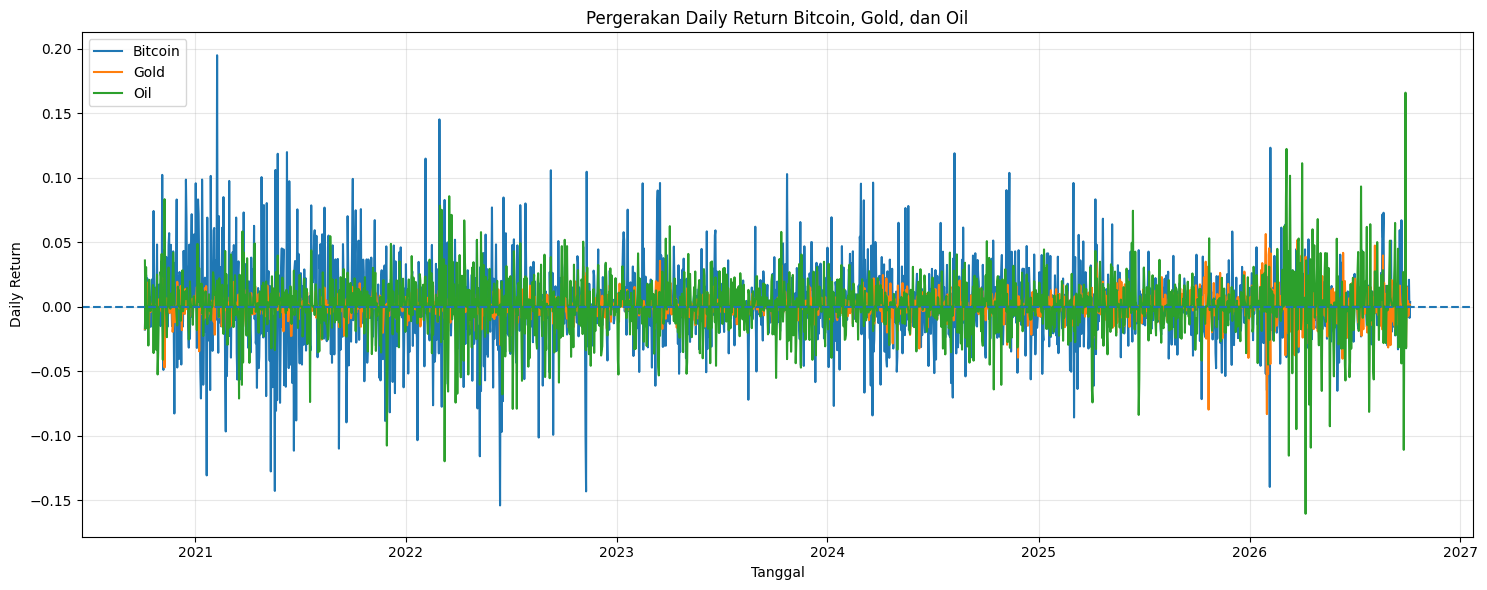

In [50]:
plt.figure(figsize=(15, 6))

plt.plot(
    analysis_data["recorded_date"],
    analysis_data["btc_return"],
    label="Bitcoin"
)

plt.plot(
    analysis_data["recorded_date"],
    analysis_data["gold_return"],
    label="Gold"
)

plt.plot(
    analysis_data["recorded_date"],
    analysis_data["oil_return"],
    label="Oil"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Pergerakan Daily Return Bitcoin, Gold, dan Oil")
plt.xlabel("Tanggal")
plt.ylabel("Daily Return")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Persiapan Data

In [51]:
# ============================================================
# PERSIAPAN DATA UNTUK XGBOOST
# ============================================================

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# Data harian dengan frekuensi tetap
base_data = merged_data[
    ["recorded_date", "btc_price", "gold_price", "oil_price"]
].copy()

base_data["recorded_date"] = pd.to_datetime(base_data["recorded_date"])
base_data = base_data.sort_values("recorded_date").set_index("recorded_date")
base_data = base_data.asfreq("D").ffill()


def buat_fitur(df):
    d = df[["btc_price", "gold_price", "oil_price"]].copy()

    # Return harian
    d["btc_ret"] = np.log(d["btc_price"]).diff()
    d["gold_ret"] = d["gold_price"].pct_change()
    d["oil_ret"] = d["oil_price"].pct_change()

    d[["gold_ret", "oil_ret"]] = (
        d[["gold_ret", "oil_ret"]]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    fitur = pd.DataFrame(index=d.index)

    # Lag return (hanya memakai informasi hingga hari sebelumnya)
    for k in [1, 2, 3, 7, 14]:
        fitur[f"btc_ret_lag{k}"] = d["btc_ret"].shift(k)

    for k in [1, 2, 3, 7]:
        fitur[f"gold_ret_lag{k}"] = d["gold_ret"].shift(k)
        fitur[f"oil_ret_lag{k}"] = d["oil_ret"].shift(k)

    # Momentum dan volatilitas
    for w in [7, 30]:
        fitur[f"btc_mom_{w}"] = d["btc_ret"].shift(1).rolling(w).mean()
        fitur[f"btc_vol_{w}"] = d["btc_ret"].shift(1).rolling(w).std()

    fitur["gold_mom_7"] = d["gold_ret"].shift(1).rolling(7).mean()
    fitur["oil_mom_7"] = d["oil_ret"].shift(1).rolling(7).mean()
    fitur["gold_vol_7"] = d["gold_ret"].shift(1).rolling(7).std()
    fitur["oil_vol_7"] = d["oil_ret"].shift(1).rolling(7).std()

    # Posisi harga terhadap rata-rata bergerak
    btc_lag = d["btc_price"].shift(1)
    for w in [7, 30]:
        fitur[f"btc_ma_ratio_{w}"] = np.log(btc_lag / btc_lag.rolling(w).mean())

    # Fitur kalender
    fitur["day_of_week"] = d.index.dayofweek
    fitur["month"] = d.index.month

    # Target: log return Bitcoin hari ini
    fitur["target"] = d["btc_ret"]
    fitur["btc_price"] = d["btc_price"]
    fitur["btc_price_prev"] = d["btc_price"].shift(1)

    return fitur


feature_data = buat_fitur(base_data).replace([np.inf, -np.inf], np.nan).dropna()

FITUR = [c for c in feature_data.columns
         if c not in ["target", "btc_price", "btc_price_prev"]]

print("Jumlah data :", len(feature_data))
print("Jumlah fitur:", len(FITUR))
print("Periode     :", feature_data.index.min(), "sampai", feature_data.index.max())

display(feature_data.head())
display(feature_data.tail())

Jumlah data : 2162
Jumlah fitur: 25
Periode     : 2020-11-05 00:00:00 sampai 2026-10-06 00:00:00


,btc_ret_lag1,btc_ret_lag2,btc_ret_lag3,btc_ret_lag7,btc_ret_lag14,gold_ret_lag1,oil_ret_lag1,gold_ret_lag2,oil_ret_lag2,gold_ret_lag3,...,oil_mom_7,gold_vol_7,oil_vol_7,btc_ma_ratio_7,btc_ma_ratio_30,day_of_week,month,target,btc_price,btc_price_prev
recorded_date,,,,,,,,,,,,,,,,,,,,,
2020-11-05,0.008914,0.034249,-0.015246,0.013384,0.013880,-0.003807,0.040865,0.008906,0.022951,0.009731,...,0.006674,0.006156,0.025670,0.028257,0.135379,3,11,0.097271,15608.21,14161.48
2020-11-06,0.097271,0.008914,0.034249,0.008250,-0.003852,0.022203,-0.010521,-0.003807,0.040865,0.008906,...,0.010269,0.008859,0.019851,0.103482,0.219251,4,11,-0.000529,15599.95,15608.21
2020-11-07,-0.000529,0.097271,0.008914,0.017044,0.014515,0.002802,-0.041234,0.022203,-0.010521,-0.003807,...,0.005571,0.008938,0.027435,0.082572,0.205698,5,11,-0.050340,14834.09,15599.95
2020-11-08,-0.050340,-0.000529,0.097271,-0.002409,-0.006208,0.000133,0.000000,0.002802,-0.041234,0.022203,...,0.005571,0.008949,0.027435,0.022047,0.145171,6,11,0.042808,15482.90,14834.09
2020-11-09,0.042808,-0.050340,-0.000529,-0.015246,0.001822,0.003812,0.000000,0.000133,0.000000,0.002802,...,0.005571,0.008466,0.027435,0.048148,0.176546,0,11,-0.009126,15342.25,15482.90


,btc_ret_lag1,btc_ret_lag2,btc_ret_lag3,btc_ret_lag7,btc_ret_lag14,gold_ret_lag1,oil_ret_lag1,gold_ret_lag2,oil_ret_lag2,gold_ret_lag3,...,oil_mom_7,gold_vol_7,oil_vol_7,btc_ma_ratio_7,btc_ma_ratio_30,day_of_week,month,target,btc_price,btc_price_prev
recorded_date,,,,,,,,,,,,,,,,,,,,,
2026-10-02,0.015351,-0.000984,0.002175,-0.003470,0.057594,-0.007883,0.0,0.015291,0.0,-0.031370,...,0.003218,0.014300,0.082496,0.009251,0.049884,4,10,-0.004061,84504.88,84848.73
2026-10-03,-0.004061,0.015351,-0.000984,0.003840,0.004428,0.004499,0.0,-0.007883,0.0,0.015291,...,0.019086,0.014691,0.065851,0.004491,0.042856,5,10,0.002805,84742.22,84504.88
2026-10-04,0.002805,-0.004061,0.015351,0.000539,-0.000915,-0.007068,0.0,0.004499,0.0,-0.007883,...,0.019086,0.014363,0.065851,0.006743,0.044229,6,10,0.020613,86507.11,84742.22
2026-10-05,0.020613,0.002805,-0.004061,-0.011975,0.064823,-0.000096,0.0,-0.007068,0.0,0.004499,...,0.019086,0.014358,0.065851,0.023891,0.062037,0,10,-0.008803,85748.96,86507.11
2026-10-06,-0.008803,0.020613,0.002805,0.002175,-0.004594,0.001970,0.0,-0.000096,0.0,-0.007068,...,-0.004615,0.014533,0.012210,0.011219,0.050811,1,10,0.003575,86056.02,85748.96


# Train-Test Split

In [52]:
# SPLIT DATA (80% TRAIN - 20% TEST), URUTAN WAKTU DIPERTAHANKAN

split_index = int(len(feature_data) * 0.8)

train = feature_data.iloc[:split_index]
test = feature_data.iloc[split_index:]

X_train, y_train = train[FITUR], train["target"]
X_test, y_test = test[FITUR], test["target"]

print("Data training :", train.shape)
print("Data testing  :", test.shape)
print("\nPeriode training:", train.index.min(), "sampai", train.index.max())
print("Periode testing :", test.index.min(), "sampai", test.index.max())

Data training : (1729, 28)
Data testing  : (433, 28)

Periode training: 2020-11-05 00:00:00 sampai 2025-07-30 00:00:00
Periode testing : 2025-07-31 00:00:00 sampai 2026-10-06 00:00:00


In [53]:
# PEMILIHAN HYPERPARAMETER XGBOOST (TimeSeriesSplit PADA DATA TRAIN)

param_dist = {
    "n_estimators": [100, 200, 300, 400, 600],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_lambda": [1, 5, 10],
    "reg_alpha": [0, 0.1, 1],
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_params = search.best_params_

hasil_tuning = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_score")
    [["params", "mean_test_score", "std_test_score"]]
    .head(10)
    .reset_index(drop=True)
)
hasil_tuning["RMSE_CV"] = -hasil_tuning["mean_test_score"]

display(hasil_tuning[["params", "RMSE_CV", "std_test_score"]])
print("Hyperparameter terpilih:", best_params)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,params,RMSE_CV,std_test_score
0,"{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha...",0.028128,0.005335
1,"{'subsample': 1.0, 'reg_lambda': 10, 'reg_alph...",0.028135,0.005307
2,"{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha...",0.028176,0.005285
3,"{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha...",0.028178,0.005283
4,"{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha...",0.028180,0.005285
5,"{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha...",0.028340,0.005514
6,"{'subsample': 0.8, 'reg_lambda': 10, 'reg_alph...",0.028350,0.005324
7,"{'subsample': 0.6, 'reg_lambda': 10, 'reg_alph...",0.028474,0.005218
8,"{'subsample': 0.8, 'reg_lambda': 10, 'reg_alph...",0.028498,0.005304
9,"{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha...",0.028508,0.005303


Hyperparameter terpilih: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


# Modeling

In [54]:
# TRAINING MODEL XGBOOST

model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **best_params
)

model.fit(X_train, y_train)

print("Model XGBoost berhasil dilatih.")
print("Parameter:", model.get_params())

Model XGBoost berhasil dilatih.
Parameter: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.01, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 2, 'max_leaves': None, 'min_child_weight': 5, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 1, 'reg_lambda': 1, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.6, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


# Prediksi

In [55]:
# PREDIKSI ONE-STEP-AHEAD PADA DATA TEST
# Interval prediksi dari residual out-of-fold pada data train

oof_resid = []
for tr_idx, va_idx in tscv.split(X_train):
    m_cv = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **best_params
    )
    m_cv.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    oof_resid.append(
        y_train.iloc[va_idx].values - m_cv.predict(X_train.iloc[va_idx])
    )

oof_resid = np.concatenate(oof_resid)
q_low, q_high = np.quantile(oof_resid, [0.025, 0.975])

pred_ret = model.predict(X_test)
prev_price = test["btc_price_prev"]

forecast = pd.Series(
    prev_price.values * np.exp(pred_ret),
    index=test.index,
    name="prediction"
)
forecast_lower = pd.Series(
    prev_price.values * np.exp(pred_ret + q_low),
    index=test.index,
    name="lower_95"
)
forecast_upper = pd.Series(
    prev_price.values * np.exp(pred_ret + q_high),
    index=test.index,
    name="upper_95"
)

display(forecast.head())

recorded_date
2025-07-31    117997.429155
2025-08-01    115924.409258
2025-08-02    113266.388393
2025-08-03    112612.745419
2025-08-04    114325.349003
Freq: D, Name: prediction, dtype: float64

# Evaluasi

In [56]:
# EVALUASI

y_true = test["btc_price"]
y_prev = test["btc_price_prev"]

def hitung_metrik(actual, pred):
    return {
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred)),
        "MAPE": np.mean(np.abs((actual - pred) / actual)) * 100,
        "R2": r2_score(actual, pred),
    }

m_xgb = hitung_metrik(y_true, forecast)
m_naive = hitung_metrik(y_true, y_prev)

arah_aktual = np.sign(y_true - y_prev)
arah_prediksi = np.sign(forecast - y_prev)
mask_arah = arah_prediksi != 0
akurasi_arah = (
    (arah_aktual[mask_arah] == arah_prediksi[mask_arah]).mean() * 100
    if mask_arah.any() else np.nan
)
coverage = ((y_true >= forecast_lower) & (y_true <= forecast_upper)).mean() * 100

print("================================")
print("HASIL EVALUASI XGBOOST")
print("================================")
print(f"MAE       : {m_xgb['MAE']:.2f}")
print(f"RMSE      : {m_xgb['RMSE']:.2f}")
print(f"MAPE      : {m_xgb['MAPE']:.2f}%")
print(f"R²        : {m_xgb['R2']:.4f}")
print("Akurasi arah naik/turun :", "tidak terdefinisi" if np.isnan(akurasi_arah) else f"{akurasi_arah:.2f}%")
print(f"Cakupan interval 95%    : {coverage:.2f}%")
print("--------------------------------")
print("PEMBANDING NAIVE (harga hari ini = harga kemarin)")
print(f"MAE       : {m_naive['MAE']:.2f}")
print(f"RMSE      : {m_naive['RMSE']:.2f}")
print(f"MAPE      : {m_naive['MAPE']:.2f}%")
print(f"R²        : {m_naive['R2']:.4f}")
print("--------------------------------")

selisih_rmse = (m_naive["RMSE"] - m_xgb["RMSE"]) / m_naive["RMSE"] * 100
print(f"Perbaikan RMSE terhadap naive: {selisih_rmse:.2f}%")

if abs(selisih_rmse) < 1:
    print("Kesimpulan: XGBoost setara dengan naive (random walk), tidak ada keunggulan prediktif yang berarti.")
elif selisih_rmse > 0:
    print("Kesimpulan: XGBoost lebih akurat daripada naive.")
else:
    print("Kesimpulan: XGBoost kurang akurat daripada naive.")

HASIL EVALUASI XGBOOST
MAE       : 1328.07
RMSE      : 1873.42
MAPE      : 1.59%
R²        : 0.9897
Akurasi arah naik/turun : 48.50%
Cakupan interval 95%    : 97.92%
--------------------------------
PEMBANDING NAIVE (harga hari ini = harga kemarin)
MAE       : 1323.35
RMSE      : 1866.71
MAPE      : 1.58%
R²        : 0.9898
--------------------------------
Perbaikan RMSE terhadap naive: -0.36%
Kesimpulan: XGBoost setara dengan naive (random walk), tidak ada keunggulan prediktif yang berarti.


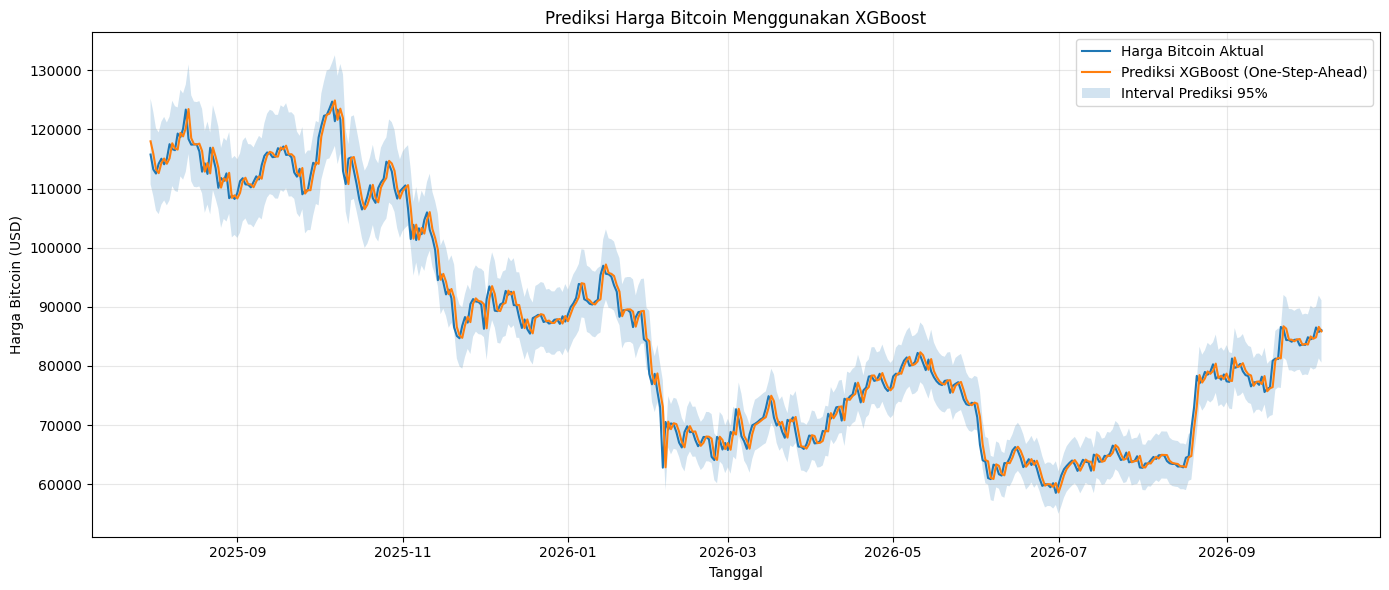

In [57]:
# VISUALISASI PREDIKSI DATA TEST

plt.figure(figsize=(14, 6))

plt.plot(test.index, y_true, label="Harga Bitcoin Aktual")
plt.plot(forecast.index, forecast, label="Prediksi XGBoost (One-Step-Ahead)")
plt.fill_between(
    test.index, forecast_lower, forecast_upper,
    alpha=0.2, label="Interval Prediksi 95%"
)

plt.title("Prediksi Harga Bitcoin Menggunakan XGBoost")
plt.xlabel("Tanggal")
plt.ylabel("Harga Bitcoin (USD)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# EVALUASI TRAINING

train_pred = pd.Series(
    train["btc_price_prev"].values * np.exp(model.predict(X_train)),
    index=train.index
)

m_train = hitung_metrik(train["btc_price"], train_pred)

print("================================")
print("TRAINING PERFORMANCE")
print("================================")
print(f"MAE  : {m_train['MAE']:.2f}")
print(f"RMSE : {m_train['RMSE']:.2f}")
print(f"MAPE : {m_train['MAPE']:.2f}%")
print(f"R²   : {m_train['R2']:.4f}")

TRAINING PERFORMANCE
MAE  : 1025.08
RMSE : 1549.70
MAPE : 2.19%
R²   : 0.9965


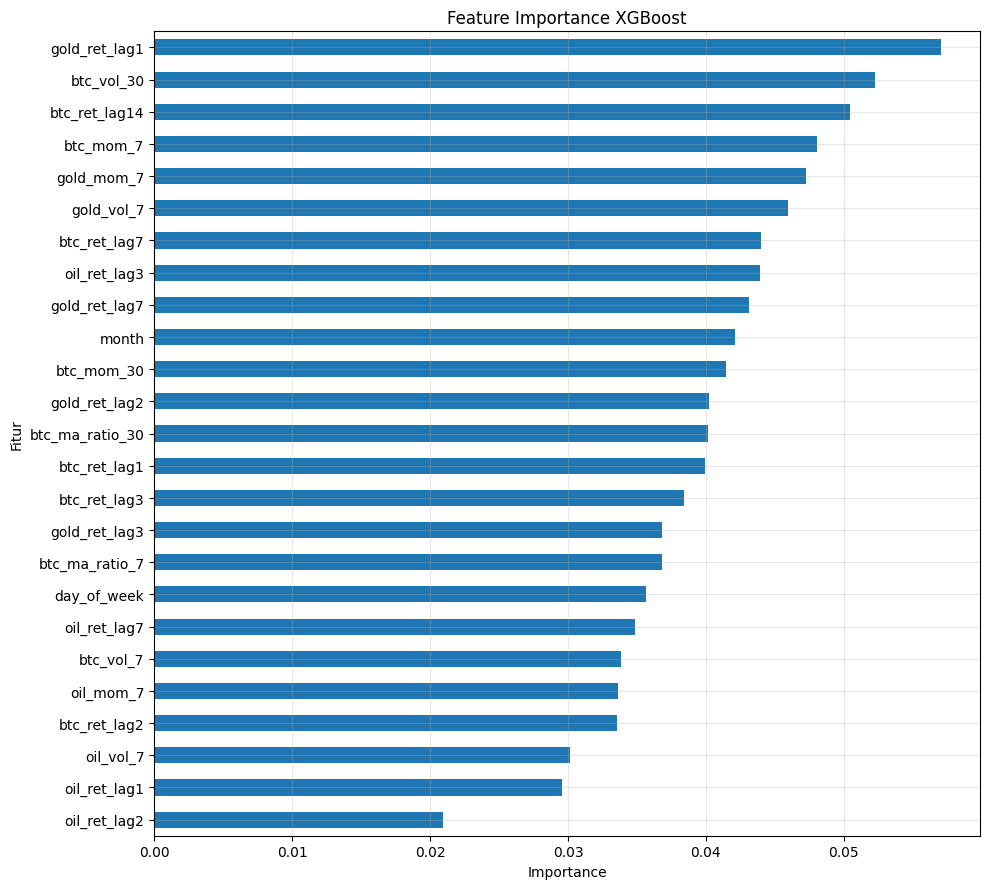

,importance
gold_ret_lag1,0.057017
btc_vol_30,0.052233
btc_ret_lag14,0.050450
btc_mom_7,0.048021
gold_mom_7,0.047276
gold_vol_7,0.045983
btc_ret_lag7,0.043967
oil_ret_lag3,0.043951
gold_ret_lag7,0.043113
month,0.042118


In [59]:
# FEATURE IMPORTANCE

importance = (
    pd.Series(model.feature_importances_, index=FITUR)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 9))
importance.plot(kind="barh")

plt.title("Feature Importance XGBoost")
plt.xlabel("Importance")
plt.ylabel("Fitur")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(importance.sort_values(ascending=False).head(10).to_frame("importance"))

In [60]:
evaluation = pd.DataFrame({
    "actual": test["btc_price"],
    "prediction": forecast
})

evaluation["error"] = evaluation["actual"] - evaluation["prediction"]
evaluation["absolute_error"] = evaluation["error"].abs()

display(evaluation.head(10))

,actual,prediction,error,absolute_error
recorded_date,,,,
2025-07-31,115761.13,117997.429155,-2236.299155,2236.299155
2025-08-01,113248.73,115924.409258,-2675.679258,2675.679258
2025-08-02,112542.74,113266.388393,-723.648393,723.648393
2025-08-03,114215.73,112612.745419,1602.984581,1602.984581
2025-08-04,115051.85,114325.349003,726.500997,726.500997
2025-08-05,114112.95,115086.919892,-973.969892,973.969892
2025-08-06,115028.83,114198.841386,829.988614,829.988614
2025-08-07,117515.49,115114.971957,2400.518043,2400.518043
2025-08-08,116683.79,117666.072075,-982.282075,982.282075


In [61]:
# MODEL FINAL (SELURUH DATA) DAN PREDIKSI REKURSIF 30 HARI
# Harga emas dan minyak ke depan diasumsikan tetap pada nilai terakhir

final_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **best_params
)
final_model.fit(feature_data[FITUR], feature_data["target"])

future_steps = 30
sim = base_data.copy()
last_price = sim["btc_price"].iloc[-1]

cum_ret = 0.0
rows = []

for h in range(1, future_steps + 1):
    next_date = sim.index[-1] + pd.Timedelta(days=1)

    row = pd.DataFrame(
        {
            "btc_price": [sim["btc_price"].iloc[-1]],
            "gold_price": [sim["gold_price"].iloc[-1]],
            "oil_price": [sim["oil_price"].iloc[-1]],
        },
        index=[next_date]
    )
    sim = pd.concat([sim, row])

    fitur_next = buat_fitur(sim)[FITUR].iloc[[-1]]
    ret_next = final_model.predict(fitur_next)[0]

    harga_next = sim["btc_price"].iloc[-2] * np.exp(ret_next)
    sim.loc[next_date, "btc_price"] = harga_next

    cum_ret += ret_next
    rows.append({
        "recorded_date": next_date,
        "predicted_btc_price": harga_next,
        "lower_95": last_price * np.exp(cum_ret + q_low * np.sqrt(h)),
        "upper_95": last_price * np.exp(cum_ret + q_high * np.sqrt(h)),
    })

future_result = pd.DataFrame(rows)

display(future_result)

,recorded_date,predicted_btc_price,lower_95,upper_95
0,2026-10-07,86143.793240,80839.721094,91412.497959
1,2026-10-08,86210.809651,78800.795877,93761.039391
2,2026-10-09,86312.203809,77315.942247,95659.313364
3,2026-10-10,86405.897414,76093.057788,97298.596781
4,2026-10-11,86508.684963,75049.196643,98789.111335
5,2026-10-12,86614.028569,74128.342917,100170.522961
6,2026-10-13,86720.997608,73299.945411,101469.587321
7,2026-10-14,86826.496372,72542.065835,102700.731677
8,2026-10-15,86919.785654,71832.496584,103863.576109
9,2026-10-16,87020.563022,71177.945303,104990.562933


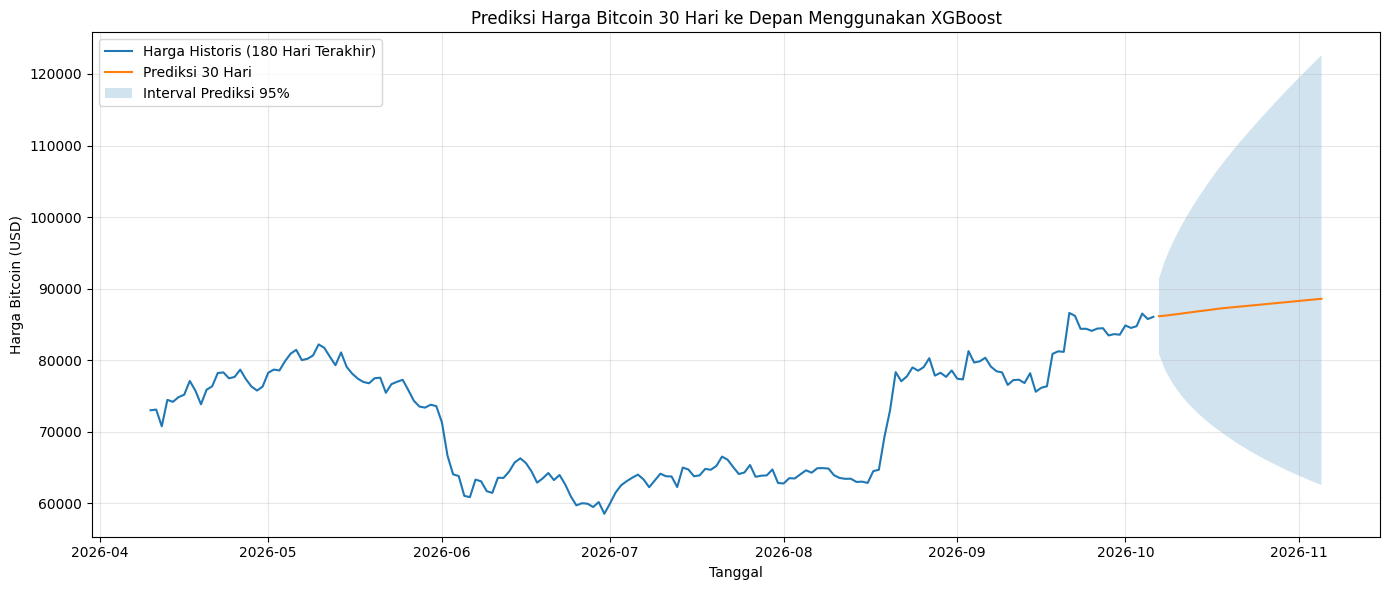

In [62]:
# VISUALISASI PREDIKSI 30 HARI

plt.figure(figsize=(14, 6))

riwayat = base_data.iloc[-180:]

plt.plot(riwayat.index, riwayat["btc_price"], label="Harga Historis (180 Hari Terakhir)")
plt.plot(
    future_result["recorded_date"],
    future_result["predicted_btc_price"],
    label="Prediksi 30 Hari"
)
plt.fill_between(
    future_result["recorded_date"],
    future_result["lower_95"],
    future_result["upper_95"],
    alpha=0.2,
    label="Interval Prediksi 95%"
)

plt.title("Prediksi Harga Bitcoin 30 Hari ke Depan Menggunakan XGBoost")
plt.xlabel("Tanggal")
plt.ylabel("Harga Bitcoin (USD)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusion

**Langkah yang Telah Dilakukan**

1. Pengumpulan Data
   * Mengambil data historis Bitcoin, emas, dan minyak periode 2020–2026.
   * Data diperoleh melalui proses ETL menggunakan Apache Airflow dan disimpan di MySQL.

2. Data Wrangling
   * Mengecek struktur dan karakteristik masing-masing dataset.
   * Mengecek missing value dan data duplikat.
   * Mengubah format tanggal dan tipe data harga.
   * Menghapus data duplikat dan data yang tidak valid.
   * Menggabungkan data Bitcoin, emas, dan minyak berdasarkan tanggal.

3. Exploratory Data Analysis (EDA)
   * Menganalisis statistik deskriptif.
   * Melihat tren perubahan harga ketiga aset.
   * Melakukan normalisasi harga untuk membandingkan perkembangan relatif.
   * Menghitung korelasi Bitcoin dengan emas dan minyak.
   * Menganalisis pola perubahan harga berdasarkan kondisi Bitcoin naik atau turun.

4. Manual Grouping
   * Perubahan harga harian Bitcoin dihitung menggunakan persentase perubahan.
   * Data Bitcoin dikelompokkan menjadi Naik, Turun, dan Tetap.
   * Kemudian dihitung rata-rata perubahan harga Bitcoin, emas, dan minyak pada setiap kelompok.
   * Hasilnya digunakan untuk melihat apakah emas dan minyak mengikuti arah pergerakan Bitcoin.

5. Pemodelan XGBoost
   * Membuat fitur berdasarkan riwayat harga dan return.
   * Membagi data menjadi data training dan testing berdasarkan urutan waktu.
   * Melakukan tuning hyperparameter menggunakan `TimeSeriesSplit`.
   * Melatih model XGBoost.
   * Melakukan prediksi dan evaluasi menggunakan MAE, RMSE, MAPE, dan R².
   * Membandingkan hasil XGBoost dengan metode naive.

---

**Simpulan Berdasarkan Pertanyaan**
1. Bagaimana tren perubahan harga Bitcoin, emas, dan minyak selama 2020–2026?**
Bitcoin memiliki pergerakan paling fluktuatif, sedangkan emas relatif lebih stabil dan minyak mengalami fluktuasi pada periode tertentu. Ketiga aset memiliki pola perubahan yang berbeda.
2. Seberapa kuat hubungan Bitcoin dan emas?
Terdapat hubungan positif yang kuat dengan nilai korelasi 0,6981. Artinya, harga Bitcoin dan emas cenderung bergerak searah selama periode penelitian.
3. Seberapa kuat hubungan Bitcoin dan minyak?
Terdapat hubungan negatif yang sangat lemah dengan nilai korelasi -0,1934. Artinya, Bitcoin dan minyak cenderung bergerak berlawanan, tetapi hubungannya sangat kecil.
4. Bagaimana pola emas dan minyak ketika Bitcoin naik atau turun?
Hasil manual grouping menunjukkan:
* Saat Bitcoin naik 2,19%, emas rata-rata naik 0,05% dan minyak 0,06%.
* Saat Bitcoin turun 1,94%, emas masih naik 0,03% dan minyak 0,07%.